In [2]:
# Install required libraries (run once)
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Using device: cuda
   GPU: Tesla T4


In [4]:
# Load the two CSV files
fake_df = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv')
true_df = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv')

# Add labels:  1 = Fake,  0 = Real
fake_df['label'] = 1
true_df['label'] = 0

# Combine into a single DataFrame and shuffle
df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle rows

print(f"Total articles : {len(df):,}")
print(f"Fake articles  : {df['label'].sum():,}")
print(f"Real articles  : {(df['label'] == 0).sum():,}")
df.head()

Total articles : 44,898
Fake articles  : 23,481
Real articles  : 21,417


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


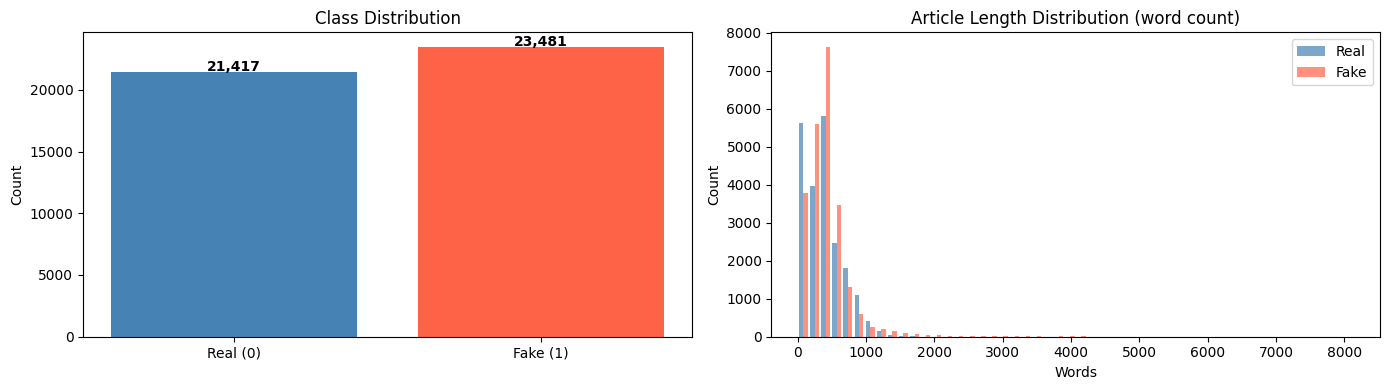


Average article length: 405 words
Max article length    : 8,135 words


In [5]:
# --- Class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
label_counts = df['label'].value_counts().sort_index()
axes[0].bar(['Real (0)', 'Fake (1)'], label_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Text length distribution
df['text_length'] = df['text'].fillna('').apply(lambda x: len(x.split()))
axes[1].hist(
    [df[df['label']==0]['text_length'], df[df['label']==1]['text_length']],
    bins=50, label=['Real', 'Fake'], color=['steelblue', 'tomato'], alpha=0.7
)
axes[1].set_title('Article Length Distribution (word count)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAverage article length: {df['text_length'].mean():.0f} words")
print(f"Max article length    : {df['text_length'].max():,} words")

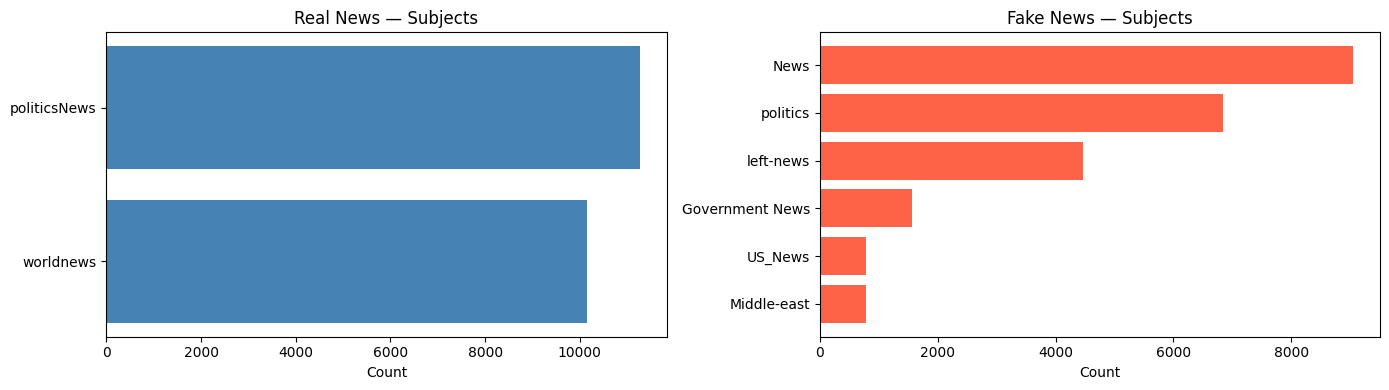

In [6]:
# --- Subject distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (label, title, color) in zip(
    axes,
    [(0, 'Real News — Subjects', 'steelblue'),
     (1, 'Fake News — Subjects', 'tomato')]
):
    counts = df[df['label'] == label]['subject'].value_counts().head(8)
    ax.barh(counts.index, counts.values, color=color)
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [7]:
def clean_text(title, text):
    """Combine title and text into one clean string."""
    title = str(title).strip()
    text  = str(text).strip()
    # We add a separator so BERT knows where title ends
    return title + ' [SEP] ' + text

df['input_text'] = df.apply(lambda row: clean_text(row['title'], row['text']), axis=1)

# Keep only what we need
df = df[['input_text', 'label']]

print("Sample input:")
print(df['input_text'].iloc[0][:300], '...')

Sample input:
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution [SEP] 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative state ...


In [8]:
# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['label']
)

# Second split: 50% val, 50% test (from the 20% temp → 10% each)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

print(f"Train size      : {len(train_df):,}")
print(f"Validation size : {len(val_df):,}")
print(f"Test size       : {len(test_df):,}")

Train size      : 35,918
Validation size : 4,490
Test size       : 4,490


In [9]:
MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 256

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    """Tokenize a batch of texts."""
    return tokenizer(
        examples['input_text'],
        padding='max_length',   # pad shorter sequences
        truncation=True,        # cut longer sequences
        max_length=MAX_LENGTH
    )

# Convert pandas DataFrames → HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df.rename(columns={'label': 'labels'}))
val_dataset   = Dataset.from_pandas(val_df.rename(columns={'label': 'labels'}))
test_dataset  = Dataset.from_pandas(test_df.rename(columns={'label': 'labels'}))

# Apply tokenization
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

# Set the format expected by PyTorch
cols = ['input_ids', 'attention_mask', 'token_type_ids', 'labels']
train_dataset.set_format(type='torch', columns=cols)
val_dataset.set_format(type='torch', columns=cols)
test_dataset.set_format(type='torch', columns=cols)

print("✅ Tokenization complete!")
print(f"   Example token IDs (first 10): {train_dataset[0]['input_ids'][:10].tolist()}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/35918 [00:00<?, ? examples/s]

Map:   0%|          | 0/4490 [00:00<?, ? examples/s]

Map:   0%|          | 0/4490 [00:00<?, ? examples/s]

✅ Tokenization complete!
   Example token IDs (first 10): [101, 8398, 5176, 4259, 2457, 2000, 3796, 3604, 7221, 6996]


In [11]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'REAL', 1: 'FAKE'},
    label2id={'REAL': 0, 'FAKE': 1}
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 109,483,778
Trainable parameters: 109,483,778


In [12]:
def compute_metrics(eval_pred):
    """Called after each evaluation step to compute accuracy."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, predictions)}


training_args = TrainingArguments(
    output_dir='./bert-fake-news',          # save checkpoints here
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',            # evaluate at the end of each epoch
    save_strategy='epoch',
    load_best_model_at_end=True,            # restore best checkpoint after training
    metric_for_best_model='accuracy',
    logging_steps=50,
    fp16=torch.cuda.is_available(),         # use 16-bit floats on GPU (faster)
    report_to='none',                       # disable WandB / MLflow logging
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # stop if val acc doesn't improve
)

print("✅ Trainer ready!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ Trainer ready!


In [13]:
print("🚀 Starting fine-tuning...\n")
train_result = trainer.train()

print("\n✅ Training complete!")
print(f"   Total training time : {train_result.metrics['train_runtime']:.0f} seconds")
print(f"   Samples per second  : {train_result.metrics['train_samples_per_second']:.1f}")

🚀 Starting fine-tuning...



Epoch,Training Loss,Validation Loss,Accuracy
1,0.000120,0.000081,1.000000
2,0.000556,0.000037,1.000000
3,0.006295,0.000026,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Training complete!
   Total training time : 2748 seconds
   Samples per second  : 39.2


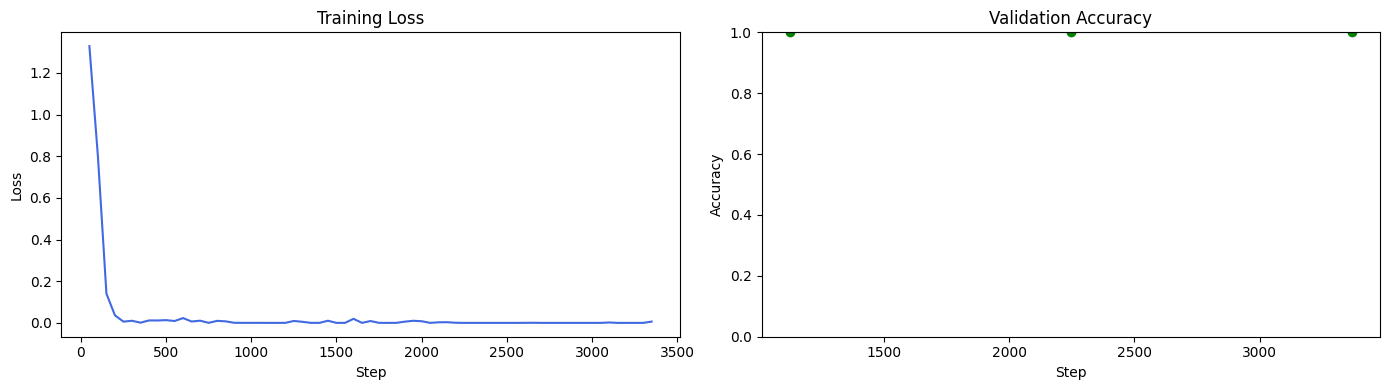

In [14]:
# Plot training loss curve
log_history = trainer.state.log_history

train_losses = [(e['step'], e['loss']) for e in log_history if 'loss' in e]
eval_accs    = [(e['step'], e['eval_accuracy']) for e in log_history if 'eval_accuracy' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, color='royalblue')
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

if eval_accs:
    steps, accs = zip(*eval_accs)
    axes[1].plot(steps, accs, marker='o', color='green')
    axes[1].set_title('Validation Accuracy')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [15]:
# Run predictions on the test set
print("Running predictions on the test set...")
raw_preds = trainer.predict(test_dataset)

y_pred = np.argmax(raw_preds.predictions, axis=-1)
y_true = raw_preds.label_ids

# --- Metrics ---
acc = accuracy_score(y_true, y_pred)
print(f"\n{'='*40}")
print(f"  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"{'='*40}\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['REAL', 'FAKE']))

Running predictions on the test set...



  Test Accuracy: 0.9991 (99.91%)

Classification Report:
              precision    recall  f1-score   support

        REAL       1.00      1.00      1.00      2142
        FAKE       1.00      1.00      1.00      2348

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490



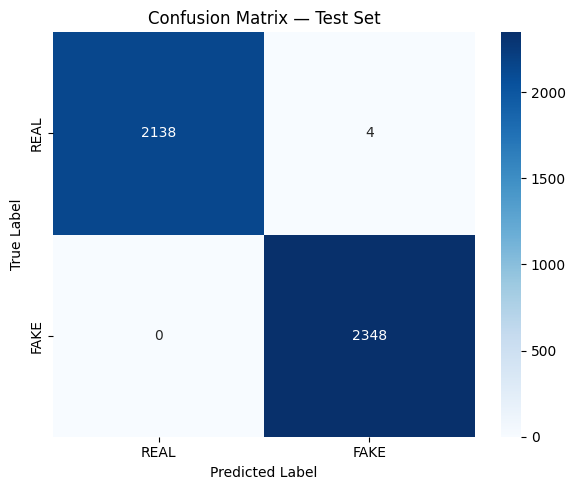

True Negatives  (Real → Real) : 2138
False Positives (Real → Fake) : 4
False Negatives (Fake → Real) : 0
True Positives  (Fake → Fake) : 2348


In [16]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['REAL', 'FAKE'],
    yticklabels=['REAL', 'FAKE']
)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Explanation
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Real → Real) : {tn}")
print(f"False Positives (Real → Fake) : {fp}")
print(f"False Negatives (Fake → Real) : {fn}")
print(f"True Positives  (Fake → Fake) : {tp}")

In [17]:
SAVE_PATH = './bert-fake-news-final'

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Model and tokenizer saved to '{SAVE_PATH}'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and tokenizer saved to './bert-fake-news-final'


In [18]:
from transformers import pipeline

# Load from saved directory
classifier = pipeline(
    task='text-classification',
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=MAX_LENGTH
)

def predict_news(text, title=''):
    """Predict whether a news article is REAL or FAKE."""
    combined = f"{title} [SEP] {text}" if title else text
    result = classifier(combined)[0]
    label = result['label']
    confidence = result['score']
    icon = '🔴 FAKE' if label == 'FAKE' else '🟢 REAL'
    print(f"Prediction  : {icon}")
    print(f"Confidence  : {confidence:.2%}")
    return label, confidence

print("--- Test with a fake-sounding article ---")
predict_news(
    title="BREAKING: Scientists confirm chocolate cures all diseases",
    text="A secret report leaked today confirms that big pharma has hidden the fact that eating chocolate daily eliminates cancer."
)

print()
print("--- Test with a real-sounding article ---")
predict_news(
    title="Federal Reserve raises interest rates by 25 basis points",
    text="The Federal Reserve announced Wednesday that it would raise its benchmark interest rate by a quarter of a percentage point, citing continued progress on inflation."
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

--- Test with a fake-sounding article ---
Prediction  : 🔴 FAKE
Confidence  : 99.97%

--- Test with a real-sounding article ---
Prediction  : 🔴 FAKE
Confidence  : 99.86%


('FAKE', 0.9986299276351929)